Total de valores nulos o NaN encontrados: 0

Distribución de segmentos por categoría:
clase
Sano_Abierto (A)          100
Sano_Cerrado (B)          100
Interictal_Externo (C)    100
Interictal_Foco (D)       100
Ictal_Crisis (E)          100
Name: count, dtype: int64


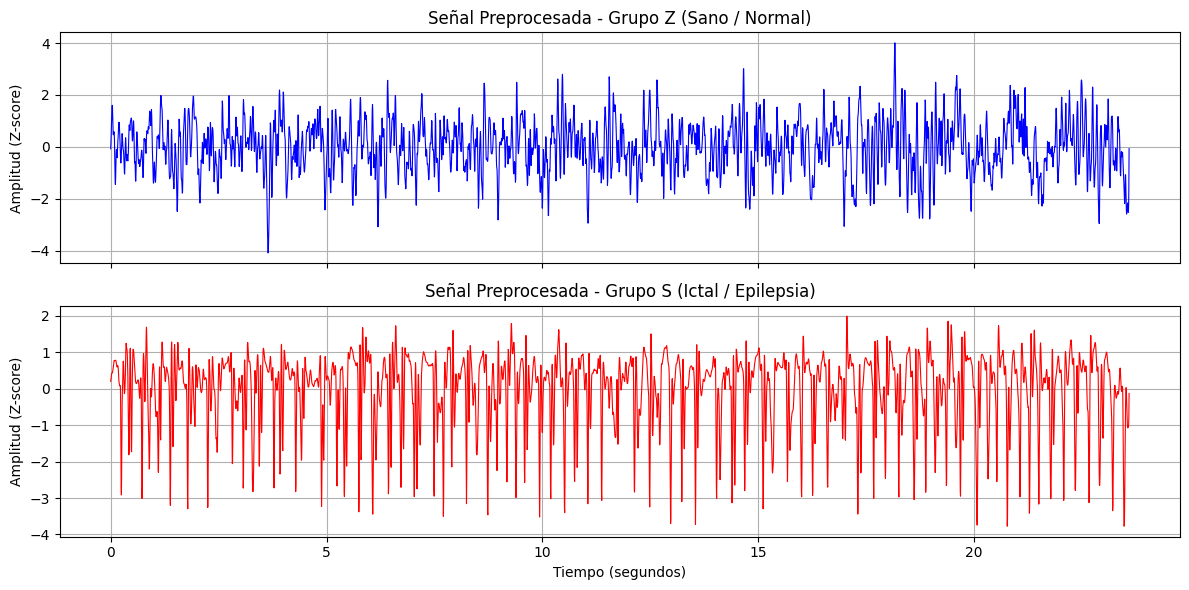

Dataset preprocesado guardado exitosamente en data/processed/dataset_fase3.pkl


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src')
from dataset import cargar_dataset_completo, verificar_calidad_datos, FS
from preprocesamiento import pipeline_preprocesamiento

# 1. Cargar el dataset completo desde la nueva estructura (Z, O, N, F, S)
df_eeg = cargar_dataset_completo('../data/raw/')
verificar_calidad_datos(df_eeg)

# 2. Filtrar usando 'carpeta_original'
# 'Z' = Sujeto sano (ojos abiertos) -> Normal
# 'S' = Actividad ictal / crisis epiléptica -> Ictal
normal_cruda = df_eeg[df_eeg['carpeta_original'] == 'Z'].iloc[0]['senal']
ictal_cruda = df_eeg[df_eeg['carpeta_original'] == 'S'].iloc[0]['senal']

# 3. Aplicar el pipeline de preprocesamiento (Fase 3)
normal_filtrado = pipeline_preprocesamiento(normal_cruda, FS)
ictal_filtrado = pipeline_preprocesamiento(ictal_cruda, FS)

# 4. Visualización comparativa
tiempo = np.arange(len(normal_cruda)) / FS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(tiempo, normal_filtrado, color='blue', linewidth=0.8)
ax1.set_title('Señal Preprocesada - Grupo Z (Sano / Normal)')
ax1.set_ylabel('Amplitud (Z-score)')
ax1.grid(True)

ax2.plot(tiempo, ictal_filtrado, color='red', linewidth=0.8)
ax2.set_title('Señal Preprocesada - Grupo S (Ictal / Epilepsia)')
ax2.set_xlabel('Tiempo (segundos)')
ax2.set_ylabel('Amplitud (Z-score)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 5. Guardar el dataset procesado para las siguientes fases
df_eeg['senal_limpia'] = df_eeg['senal'].apply(lambda x: pipeline_preprocesamiento(x, FS))
df_eeg.drop(columns=['senal']).to_pickle('../data/processed/dataset_fase3.pkl')
print("Dataset preprocesado guardado exitosamente en data/processed/dataset_fase3.pkl")